In [107]:
!pip install pandas

In [108]:
#ReservoirX

In [109]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

import random

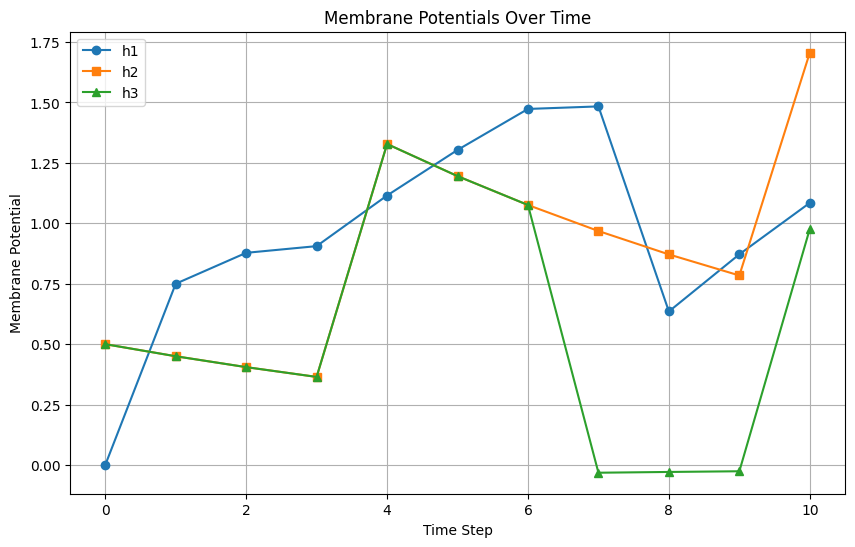

In [110]:
l1 = snn.Leaky(beta=0.9)
l2 = snn.Leaky(beta=0.9)
l3 = snn.Leaky(beta=0.9)

h1 = []
h2 =[]
h3 = []


time_steps = 10
mem1 = torch.zeros(1) 
mem2 = torch.zeros(1) 
mem3 = torch.zeros(1)

x1, mem1 = l1(torch.tensor([0.5]), mem1)
h1.append(x1)
x2, mem2 = l2(x1 + torch.tensor([0.5]), mem2)
h2.append(mem2)
x3, mem3 = l3(x2 + torch.tensor([0.5]), mem3)
h3.append(mem3)
for _ in range(time_steps):
  x1, mem1 = l1(x3[0] + torch.rand(1).clamp(-1, 0.3), mem1)
  h1.append(mem1)
  x2, mem2 = l2(x1, mem2)
  h2.append(mem2)
  x3, mem3 = l3(x2, mem3)
  h3.append(mem3)


plt.figure(figsize=(10, 6))
plt.plot(h1, label='h1', marker='o')
plt.plot(h2, label='h2', marker='s')
plt.plot(h3, label='h3', marker='^')
plt.xlabel('Time Step')
plt.ylabel('Membrane Potential')
plt.title('Membrane Potentials Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [111]:
class Neuron(): # need to add __str__ 
    def __init__(self, beta = 0.9):
        self.neuron = snn.Leaky(beta = 0.9)
        self.connections = []
        self.weights = []
        self.history = []
        self.input_spikes = torch.tensor(0.0)
        self.spike = torch.tensor(0.0)
        self.mem = torch.tensor(0.0)

    def add_connection(self, n, weight = 0.7, randomize_weight = True): # Randomize weight overrides the given weight, if any
        self.connections.append(n)
        self.weights.append(np.random.random() if randomize_weight else weight)

    def add_connections(self, n_arr: list):
        for n in n_arr:
            self.add_connection(n)

    def receive_spike(self, input):
        self.input_spikes += torch.tensor(input)

    def send_spike(self):
        for i, c in enumerate(self.connections):
            c.receive_spike(self.spike * min(self.weights[i], 0.3))

    def time_step(self):
        self.spike, self.mem = self.neuron(self.input_spikes, self.mem)
        self.history.append({
            "input" : self.input_spikes,
            "spike" : self.spike,
            "mem": self.mem
        })
        self.input_spikes = torch.tensor(0.0)
            

In [112]:
n1 = Neuron()
n2 = Neuron()
n3 = Neuron()
n1.add_connection(n2)
n2.add_connection(n3)
n3.add_connection(n1)

time_steps = 20
for _ in range(time_steps):
    n1.receive_spike(min(np.random.random(), 0.4))

In [113]:
def init_neurons(num:int) -> list:
    neurons = []
    for i in range(num):
        neurons.append(Neuron())
    
    return neurons

def make_connections(neurons: list, num_connections = 1) -> list:
    for neuron in neurons:
        neuron.add_connections(random.sample(neurons, num_connections))


In [114]:
num_neurons = 5
neurons = init_neurons(num_neurons)
make_connections(neurons, num_connections = 2)

do = True
if do:
    print(neurons)
    for i in neurons:
        print(i, i.connections)

time_steps = 20
for _ in range(time_steps):
    for i, n in enumerate(neurons):
        n.receive_spike(min(np.random.random(), 0.4))
        n.time_step()
        n.send_spike()

[<__main__.Neuron object at 0x7026bbde42b0>, <__main__.Neuron object at 0x7026bbde4510>, <__main__.Neuron object at 0x7026dee0d490>, <__main__.Neuron object at 0x70257615acf0>, <__main__.Neuron object at 0x7025761596a0>]
<__main__.Neuron object at 0x7026bbde42b0> [<__main__.Neuron object at 0x7026bbde4510>, <__main__.Neuron object at 0x7026bbde42b0>]
<__main__.Neuron object at 0x7026bbde4510> [<__main__.Neuron object at 0x70257615acf0>, <__main__.Neuron object at 0x7026dee0d490>]
<__main__.Neuron object at 0x7026dee0d490> [<__main__.Neuron object at 0x7026bbde42b0>, <__main__.Neuron object at 0x7026dee0d490>]
<__main__.Neuron object at 0x70257615acf0> [<__main__.Neuron object at 0x7026dee0d490>, <__main__.Neuron object at 0x7026bbde4510>]
<__main__.Neuron object at 0x7025761596a0> [<__main__.Neuron object at 0x7026bbde4510>, <__main__.Neuron object at 0x7026dee0d490>]


/tmp/ipykernel_45293/696153108.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.input_spikes += torch.tensor(input)


In [115]:
neurons[0].history

[{'input': tensor(0.4000), 'spike': tensor(0.), 'mem': tensor(0.4000)},
 {'input': tensor(0.1911), 'spike': tensor(0.), 'mem': tensor(0.5511)},
 {'input': tensor(0.4000), 'spike': tensor(0.), 'mem': tensor(0.8960)},
 {'input': tensor(0.1080), 'spike': tensor(0.), 'mem': tensor(0.9144)},
 {'input': tensor(0.5817), 'spike': tensor(1.), 'mem': tensor(1.4046)},
 {'input': tensor(0.7000), 'spike': tensor(0.), 'mem': tensor(0.9642)},
 {'input': tensor(0.7000), 'spike': tensor(1.), 'mem': tensor(1.5677)},
 {'input': tensor(0.6344), 'spike': tensor(1.), 'mem': tensor(1.0454)},
 {'input': tensor(0.7000), 'spike': tensor(0.), 'mem': tensor(0.6409)},
 {'input': tensor(0.7000), 'spike': tensor(1.), 'mem': tensor(1.2768)},
 {'input': tensor(0.7000), 'spike': tensor(0.), 'mem': tensor(0.8491)},
 {'input': tensor(0.3302), 'spike': tensor(1.), 'mem': tensor(1.0944)},
 {'input': tensor(0.8782), 'spike': tensor(0.), 'mem': tensor(0.8631)},
 {'input': tensor(0.7000), 'spike': tensor(1.), 'mem': tensor(1.

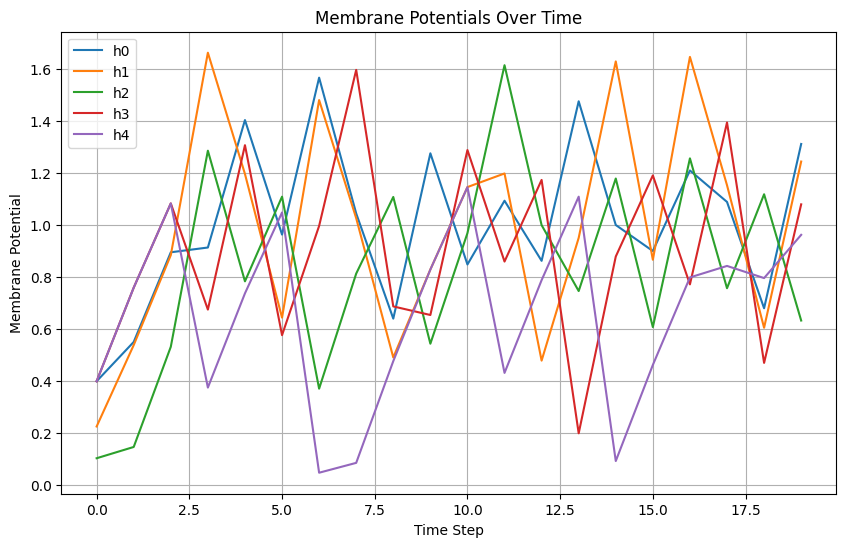

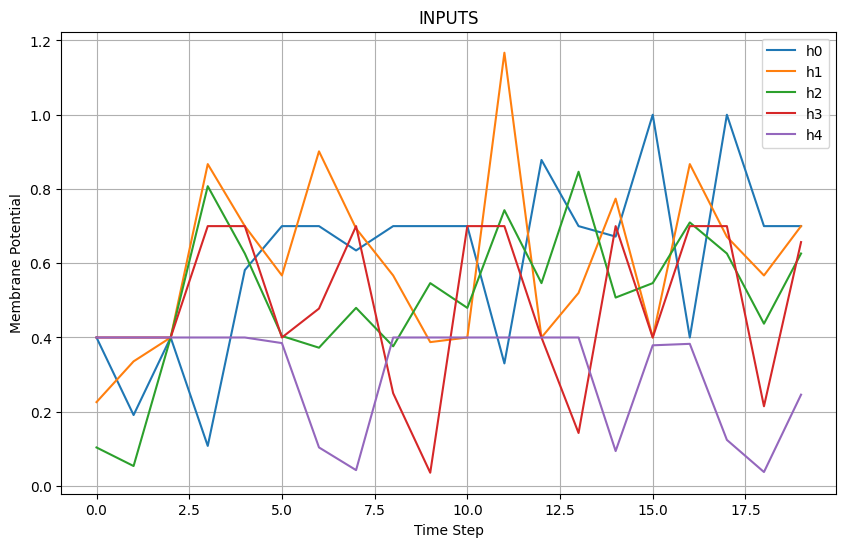

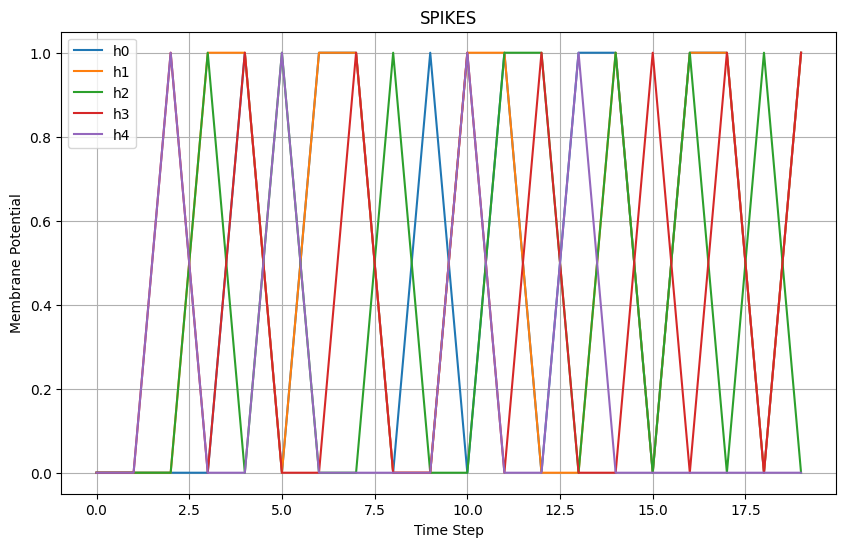

In [117]:
plt.figure(figsize=(10, 6))
for i, n in enumerate(neurons):
    plt.plot([x["mem"] for x in n.history], label=f'h{i}')

plt.xlabel('Time Step')
plt.ylabel('Membrane Potential')
plt.title('Membrane Potentials Over Time')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for i, n in enumerate(neurons):
    plt.plot([x["input"] for x in n.history], label=f'h{i}')

plt.xlabel('Time Step')
plt.ylabel('Membrane Potential')
plt.title('INPUTS')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for i, n in enumerate(neurons):
    plt.plot([x["spike"] for x in n.history], label=f'h{i}')

plt.xlabel('Time Step')
plt.ylabel('Membrane Potential')
plt.title('SPIKES')
plt.legend()
plt.grid(True)
plt.show()